In [1]:
#imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from datetime import datetime

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [2]:
# loading the dataset


path = "/kaggle/input/brazilian-ecommerce/"

orders = pd.read_csv(path + "olist_orders_dataset.csv")
order_items = pd.read_csv(path + "olist_order_items_dataset.csv")
payments = pd.read_csv(path + "olist_order_payments_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
sellers = pd.read_csv(path + "olist_sellers_dataset.csv")
products = pd.read_csv(path + "olist_products_dataset.csv")
reviews = pd.read_csv(path + "olist_order_reviews_dataset.csv")
geolocation = pd.read_csv(path + "olist_geolocation_dataset.csv")
cat_trans    = pd.read_csv(path + "product_category_name_translation.csv")

# Basic sanity check

In [4]:

dfs = {
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "customers": customers,
    "sellers": sellers,
    "products": products,
    "reviews": reviews,
    "geolocation": geolocation,
    "cat_trans": cat_trans,
}

for name, df in dfs.items():
    print(f"\n{name.upper()}")
    print(df.shape)
    display(df.head())


ORDERS
(99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



ORDER_ITEMS
(112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



PAYMENTS
(103886, 5)


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



GEOLOCATION
(1000163, 5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



CAT_TRANS
(71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


# Making formats consistent

In [5]:
# Convert dates
order_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_cols:
    orders[col] = pd.to_datetime(orders[col])

order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])

review_date_cols = [
    "review_creation_date",
    "review_answer_timestamp"
]

for col in review_date_cols:
    reviews[col] = pd.to_datetime(reviews[col])

In [6]:
# Aggregate order_items to order level
order_items_agg = order_items.groupby("order_id").agg({
    "price": "sum",
    "freight_value": "sum"
}).reset_index()

# Aggregate payments
payments_agg = payments.groupby("order_id").agg({
    "payment_value": "sum",
    "payment_installments": "max"
}).reset_index()

# Aggregate reviews
reviews_agg = reviews.groupby("order_id").agg({
    "review_score": "mean"
}).reset_index()


# Data Quality

In [7]:
def missing_report(df, name):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(1)
    report = pd.DataFrame({'missing_count': miss, 'missing_pct': pct})
    report = report[report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
    print(f'\n── {name} ({df.shape[0]:,} rows) ──')
    print(report.to_string() if not report.empty else '  No missing values ✓')


In [8]:
for name, df in dfs.items():
    missing_report(df, name)


── orders (99,441 rows) ──
                               missing_count  missing_pct
order_delivered_customer_date           2965          3.0
order_delivered_carrier_date            1783          1.8
order_approved_at                        160          0.2

── order_items (112,650 rows) ──
  No missing values ✓

── payments (103,886 rows) ──
  No missing values ✓

── customers (99,441 rows) ──
  No missing values ✓

── sellers (3,095 rows) ──
  No missing values ✓

── products (32,951 rows) ──
                            missing_count  missing_pct
product_category_name                 610          1.9
product_name_lenght                   610          1.9
product_description_lenght            610          1.9
product_photos_qty                    610          1.9
product_weight_g                        2          0.0
product_length_cm                       2          0.0
product_height_cm                       2          0.0
product_width_cm                        2          0.0

──

In [5]:
print("Count of unique order IDs in orders table: ",orders['order_id'].nunique())
print("Count of unique order IDs in order items table: ",order_items['order_id'].nunique())

print("Difference in id counts (orders - order items: ", orders['order_id'].nunique() - order_items['order_id'].nunique())

Count of unique order IDs in orders table:  99441
Count of unique order IDs in order items table:  98666
Difference in id counts (orders - order items:  775


In [6]:
# checking if all orders are present in order_items

# Filter orders not in order_items
missing_items_orders = orders[~orders['order_id'].isin(order_items['order_id'])]

# Aggregate count by order_status
status_counts = missing_items_orders['order_status'].value_counts()
print(status_counts)

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64


In [10]:
# checking if all order items are present in orders

# Filter order_items not in order
missing_orders = order_items[~order_items['order_id'].isin(orders['order_id'])]

# Aggregate count by order_status
items_counts = missing_orders.value_counts()
print(items_counts)

Series([], Name: count, dtype: int64)


## Reviews Deep Dive
Focusing on finding out the customer pain points

In [22]:
# Score distribution
score_counts = reviews['review_score'].value_counts().sort_index()
print(score_counts)

score_pct = (score_counts / len(reviews) * 100).round(1)
print(score_pct)

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64
review_score
1    11.5
2     3.2
3     8.2
4    19.3
5    57.8
Name: count, dtype: float64



Reviews with titles: 11568 (11.7%)
Reviews without titles: 87656 (88.3%)


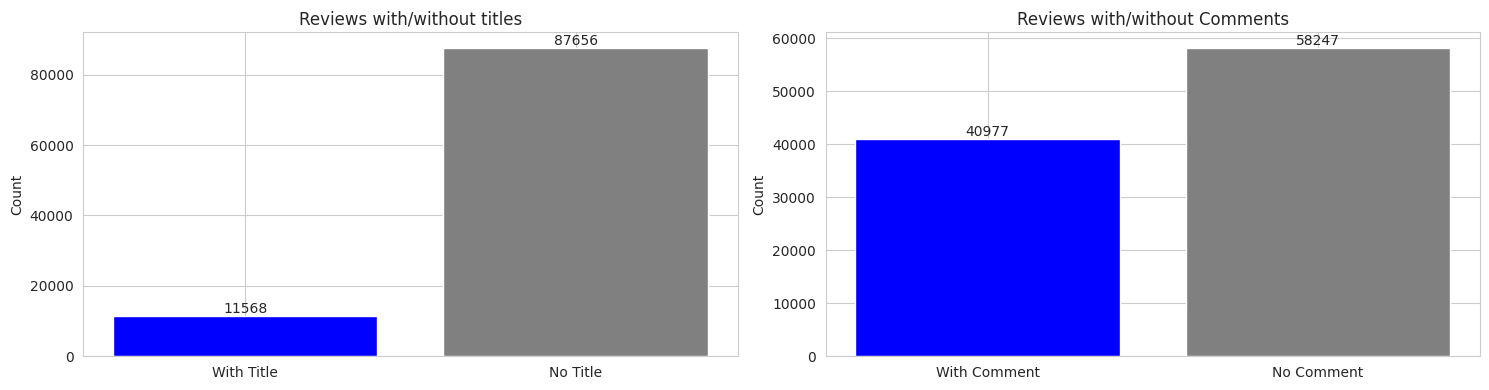


Reviews with comments: 40977 (41.3%)
Reviews without comments: 58247 (58.7%)


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Review title vs no title
has_title = reviews['review_comment_title'].notna().sum()
no_title = len(reviews) - has_title


axes[0].bar(['With Title', 'No Title'], [has_title, no_title], color=['blue', 'gray'])
axes[0].set_title('Reviews with/without titles', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate([has_title, no_title]):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

print(f"\nReviews with titles: {has_title} ({has_title/len(reviews)*100:.1f}%)")
print(f"Reviews without titles: {no_title} ({no_title/len(reviews)*100:.1f}%)")

# Comments vs no comments
has_comment = reviews['review_comment_message'].notna().sum()
no_comment = len(reviews) - has_comment


axes[1].bar(['With Comment', 'No Comment'], [has_comment, no_comment], color=['blue', 'gray'])
axes[1].set_title('Reviews with/without Comments', fontsize=12)
axes[1].set_ylabel('Count')
for i, v in enumerate([has_comment, no_comment]):
    axes[1].text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"\nReviews with comments: {has_comment} ({has_comment/len(reviews)*100:.1f}%)")
print(f"Reviews without comments: {no_comment} ({no_comment/len(reviews)*100:.1f}%)")


In [42]:
has_comment_df = reviews[reviews['review_comment_message'].notna()].copy()

print("Score distribution of reviews with comments:")
# Score distribution
has_comment_score_counts = has_comment_df['review_score'].value_counts().sort_index()
print(has_comment_score_counts)

has_comment_score_pct = (has_comment_score_counts / len(has_comment_df) * 100).round(1)
print(has_comment_score_pct)

Score distribution of reviews with comments:
review_score
1     8745
2     2145
3     3557
4     5976
5    20554
Name: count, dtype: int64
review_score
1    21.3
2     5.2
3     8.7
4    14.6
5    50.2
Name: count, dtype: float64


### What do 1-star and 2-star reviews mention?

In [30]:
# Merge reviews with orders to get timestamps
reviews_with_orders = reviews.merge(
    orders[['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 
               'order_estimated_delivery_date', 'customer_id']],
    on='order_id',
    how='left'
)

# Ensure datetime columns (safe even if already parsed)
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 
             'order_estimated_delivery_date', 'review_answer_timestamp']
for col in date_cols:
    if col in reviews_with_orders.columns:
        reviews_with_orders[col] = pd.to_datetime(reviews_with_orders[col])

# Recalculate (handle NaNs properly)
reviews_with_orders['delivery_delay_days'] = (
    reviews_with_orders['order_delivered_customer_date'].sub(
        reviews_with_orders['order_estimated_delivery_date'], fill_value=pd.NaT
    ).dt.days
)

# Delivery status (fills NaN delay as 'Not Delivered')
reviews_with_orders['delivery_status'] = 'On Time'
reviews_with_orders.loc[reviews_with_orders['delivery_delay_days'] > 0, 'delivery_status'] = 'Late'
reviews_with_orders.loc[reviews_with_orders['order_delivered_customer_date'].isna(), 'delivery_status'] = 'Not Delivered'

# Review timing
reviews_with_orders['days_to_review'] = (
    reviews_with_orders['review_answer_timestamp'] - reviews_with_orders['order_purchase_timestamp']
).dt.days


### Text Analysis: What Do Bad Reviews Say?

In [36]:
# ### Key Insight - The Pain Point Vocabulary:
# 
# **Bad reviews are dominated by:**
# - **entrega** (delivery) - #1 pain point
# - **prazo** (deadline)
# - **atraso** (delay)
# - **produto** (product) - but often with negative context
# - **recebi** (received) - often "não recebi" (didn't receive)
# - **péssimo** (terrible)


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Bad reviews with comments: 10890
Good reviews with comments: 26530


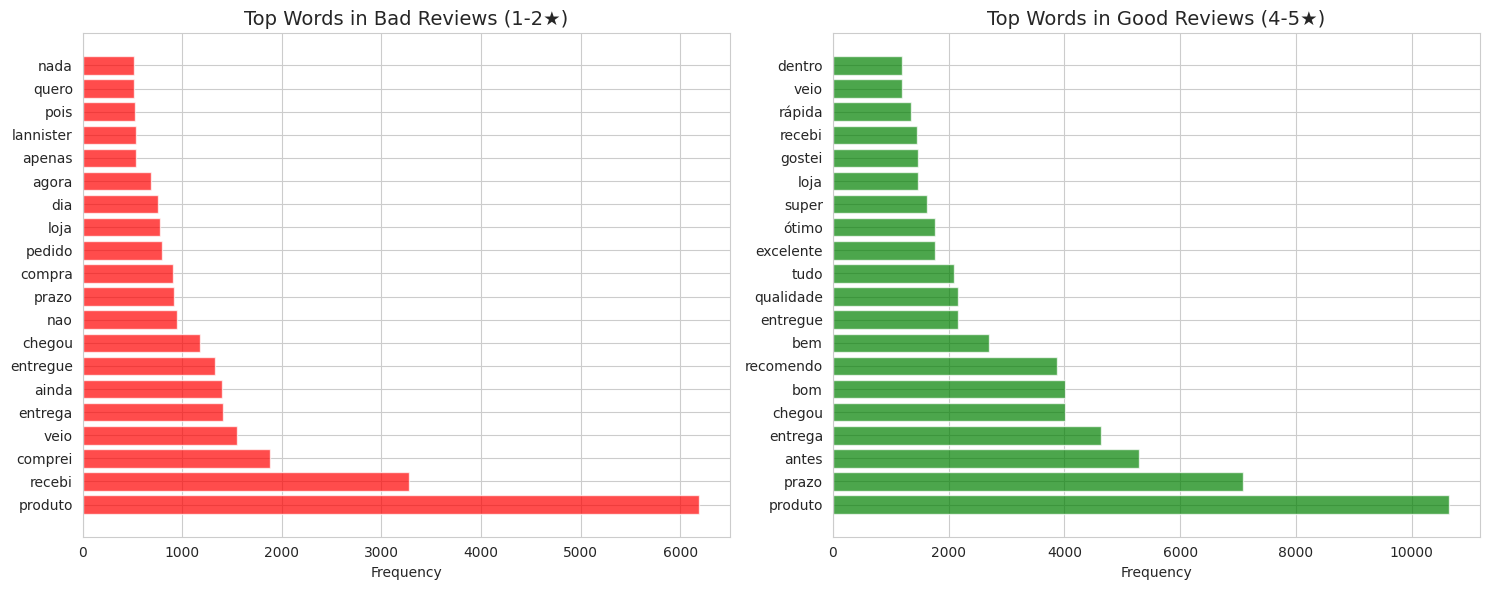


=== TOP WORDS IN BAD REVIEWS ===
produto: 6189
recebi: 3273
comprei: 1882
veio: 1552
entrega: 1412
ainda: 1401
entregue: 1329
chegou: 1180
nao: 949
prazo: 916
compra: 909
pedido: 794
loja: 775
dia: 762
agora: 689

=== TOP WORDS IN GOOD REVIEWS ===
produto: 10646
prazo: 7077
antes: 5281
entrega: 4633
chegou: 4016
bom: 4008
recomendo: 3873
bem: 2697
entregue: 2165
qualidade: 2162
tudo: 2094
excelente: 1768
ótimo: 1759
super: 1629
loja: 1470


In [35]:
# For text analysis
import re
from collections import Counter
from wordcloud import WordCloud, STOPWORDS
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer
import string

# For Portuguese text processing
portuguese_stopwords = stopwords.words('portuguese')
stemmer = RSLPStemmer()

bad_reviews = reviews_with_orders[
    (reviews_with_orders['review_score'] <= 2) & 
    (reviews_with_orders['review_comment_message'].notna())
].copy()

good_reviews = reviews_with_orders[
    (reviews_with_orders['review_score'] >= 4) & 
    (reviews_with_orders['review_comment_message'].notna())
].copy()

print(f"Bad reviews with comments: {len(bad_reviews)}")
print(f"Good reviews with comments: {len(good_reviews)}")

# %%
# Text preprocessing function for Portuguese
def preport(text):
    if pd.isna(text):
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and digits
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Tokenize and remove stopwords
def tokenize_pt(text):
    if not text:
        return []
    words = word_tokenize(text, language='portuguese')
    # Remove stopwords and short words
    words = [w for w in words if w not in portuguese_stopwords and len(w) > 2]
    return words

# Apply preprocessing
bad_reviews['clean_text'] = bad_reviews['review_comment_message'].apply(preport)
good_reviews['clean_text'] = good_reviews['review_comment_message'].apply(preport)

# Tokenize
bad_reviews['tokens'] = bad_reviews['clean_text'].apply(tokenize_pt)
good_reviews['tokens'] = good_reviews['clean_text'].apply(tokenize_pt)

# %%
# Get all tokens from bad and good reviews
bad_tokens = [token for tokens in bad_reviews['tokens'] for token in tokens]
good_tokens = [token for tokens in good_reviews['tokens'] for token in tokens]

# Count frequencies
bad_token_freq = Counter(bad_tokens).most_common(30)
good_token_freq = Counter(good_tokens).most_common(30)

# Create DataFrames for plotting
bad_freq_df = pd.DataFrame(bad_token_freq, columns=['word', 'count'])
good_freq_df = pd.DataFrame(good_token_freq, columns=['word', 'count'])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bad reviews top words
axes[0].barh(bad_freq_df['word'][:20], bad_freq_df['count'][:20], color='red', alpha=0.7)
axes[0].set_title('Top Words in Bad Reviews (1-2★)', fontsize=14)
axes[0].set_xlabel('Frequency')

# Good reviews top words
axes[1].barh(good_freq_df['word'][:20], good_freq_df['count'][:20], color='green', alpha=0.7)
axes[1].set_title('Top Words in Good Reviews (4-5★)', fontsize=14)
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

print("\n=== TOP WORDS IN BAD REVIEWS ===")
for word, count in bad_token_freq[:15]:
    print(f"{word}: {count}")

print("\n=== TOP WORDS IN GOOD REVIEWS ===")
for word, count in good_token_freq[:15]:
    print(f"{word}: {count}")


=== Context for 'recebi' (I received) ===
recebi: 3036
produto: 1362
ainda: 549
comprei: 264
nao: 245
apenas: 226
agora: 155
produtos: 132
momento: 130
dois: 106
prazo: 96
pedido: 87
somente: 85
hoje: 82
mercadoria: 78

Reviews saying 'não recebi' (didn't receive): 1806
Percentage of 'recebi' mentions that are negative: 55.2%

=== Context for 'veio' (it came) ===
veio: 1395
produto: 491
comprei: 119
defeito: 119
faltando: 99
errado: 97
pedi: 63
cor: 61
porém: 59
diferente: 56
outro: 55
pedido: 53
apenas: 47
caixa: 47
dois: 44

=== Types of Damage Mentioned ===
quebrado: 128
defeito: 275
riscado: 35
amassado: 32
incompleto: 275

=== Context for 'prazo' (deadline) ===
prazo: 858
entrega: 318
produto: 216
recebi: 102
chegou: 89
entregue: 86
passou: 84
dia: 84
dentro: 75
antes: 71
ainda: 59
porém: 50
dias: 50
veio: 38
nao: 29

=== Deadline-Related Phrases ===
dentro do prazo: 76
fora do prazo: 23
prazo estourado: 0
prazo expirado: 3

=== Negative Product Contexts ===
produto não funciona: 

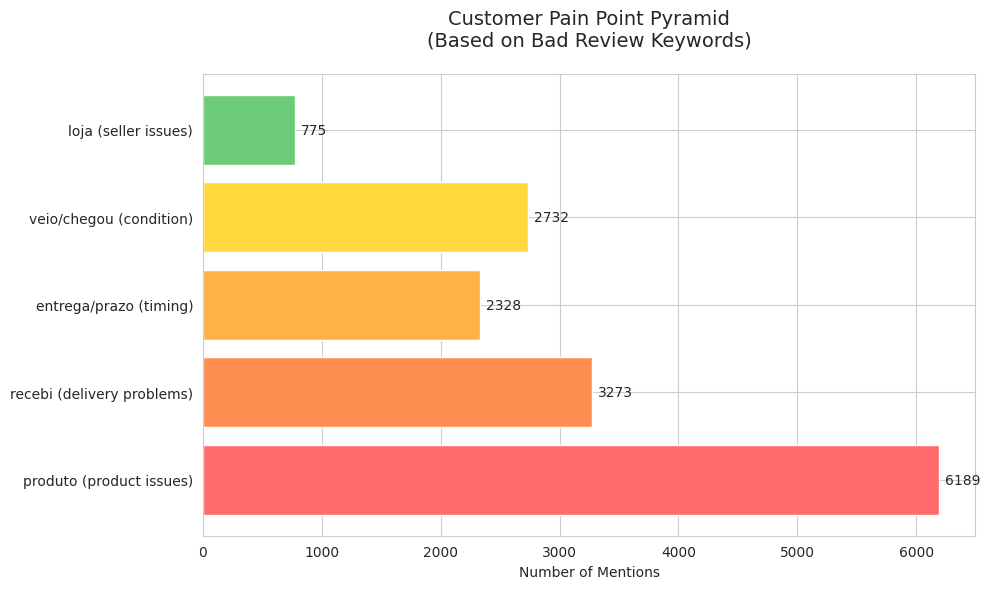

In [37]:
# ## Advanced Word Pattern Analysis

# %%
# Function to find common phrases/contexts for key words
def analyze_word_context(word, reviews_df, context_words=5):
    """
    Find the most common words that appear near a given word
    """
    from nltk.tokenize import word_tokenize
    import re
    
    contexts = []
    for review in reviews_df['review_comment_message'].dropna():
        if word in review.lower():
            # Get surrounding words (simple approach)
            words = word_tokenize(review.lower(), language='portuguese')
            if word in words:
                idx = words.index(word)
                start = max(0, idx - context_words)
                end = min(len(words), idx + context_words + 1)
                context = words[start:end]
                contexts.append(' '.join(context))
    
    # Count frequent patterns in contexts
    context_text = ' '.join(contexts)
    context_words = word_tokenize(context_text, language='portuguese')
    context_words = [w for w in context_words if w not in portuguese_stopwords and len(w) > 2]
    
    return Counter(context_words).most_common(15)

# %% [markdown]
# ### What's really happening with "recebi" (I received)?

# %%
recebi_context = analyze_word_context('recebi', bad_reviews)
print("=== Context for 'recebi' (I received) ===")
for word, count in recebi_context:
    print(f"{word}: {count}")

# Let's check the negation pattern
nao_recebi_count = bad_reviews['review_comment_message'].str.contains(
    'não recebi|nao recebi', case=False, na=False
).sum()
print(f"\nReviews saying 'não recebi' (didn't receive): {nao_recebi_count}")
print(f"Percentage of 'recebi' mentions that are negative: {nao_recebi_count/3273*100:.1f}%")

# %% [markdown]
# ### What's arriving broken? (veio)

# %%
veio_context = analyze_word_context('veio', bad_reviews)
print("\n=== Context for 'veio' (it came) ===")
for word, count in veio_context:
    print(f"{word}: {count}")

# Check common damage patterns
damage_patterns = {
    'quebrado': bad_reviews['review_comment_message'].str.contains('quebrado|quebrou', case=False, na=False).sum(),
    'defeito': bad_reviews['review_comment_message'].str.contains('defeito|defeituoso', case=False, na=False).sum(),
    'riscado': bad_reviews['review_comment_message'].str.contains('riscado|arranhado', case=False, na=False).sum(),
    'amassado': bad_reviews['review_comment_message'].str.contains('amassado', case=False, na=False).sum(),
    'incompleto': bad_reviews['review_comment_message'].str.contains('incompleto|faltando', case=False, na=False).sum()
}

print("\n=== Types of Damage Mentioned ===")
for damage, count in damage_patterns.items():
    print(f"{damage}: {count}")

# %% [markdown]
# ### The "prazo" problem (deadline/delivery time)

# %%
prazo_context = analyze_word_context('prazo', bad_reviews)
print("\n=== Context for 'prazo' (deadline) ===")
for word, count in prazo_context:
    print(f"{word}: {count}")

# Check patterns around deadlines
deadline_patterns = {
    'dentro do prazo': bad_reviews['review_comment_message'].str.contains('dentro do prazo', case=False, na=False).sum(),
    'fora do prazo': bad_reviews['review_comment_message'].str.contains('fora do prazo', case=False, na=False).sum(),
    'prazo estourado': bad_reviews['review_comment_message'].str.contains('prazo estourado', case=False, na=False).sum(),
    'prazo expirado': bad_reviews['review_comment_message'].str.contains('prazo expirado', case=False, na=False).sum()
}

print("\n=== Deadline-Related Phrases ===")
for phrase, count in deadline_patterns.items():
    print(f"{phrase}: {count}")

# %% [markdown]
# ### Product quality issues (produto + negative context)

# %%
# Find what comes after "produto"
produto_negative_patterns = {
    'produto não funciona': bad_reviews['review_comment_message'].str.contains('produto não funciona|produto nao funciona', case=False, na=False).sum(),
    'produto com defeito': bad_reviews['review_comment_message'].str.contains('produto com defeito|produto defeituoso', case=False, na=False).sum(),
    'produto diferente': bad_reviews['review_comment_message'].str.contains('produto diferente', case=False, na=False).sum(),
    'produto pequeno': bad_reviews['review_comment_message'].str.contains('produto pequeno|produto grande', case=False, na=False).sum(),
    'produto quebrado': bad_reviews['review_comment_message'].str.contains('produto quebrado', case=False, na=False).sum()
}

print("\n=== Negative Product Contexts ===")
total_produto_mentions = 6189
for issue, count in produto_negative_patterns.items():
    pct = count / total_produto_mentions * 100
    print(f"{issue}: {count} ({pct:.1f}% of produto mentions)")

# %% [markdown]
# ## The Critical Finding: Pain Point Translation

# %%
# Create a translation dictionary for pain points
pain_point_translation = {
    'produto': {
        'translation': 'product',
        'pain_contexts': ['defective', 'different than expected', 'wrong size'],
        'frequency': 6189,
        'action': 'Improve product descriptions and quality checks'
    },
    'recebi': {
        'translation': 'received',
        'pain_contexts': ['never received', 'received damaged', 'received late'],
        'frequency': 3273,
        'action': 'Fix delivery tracking and carrier issues'
    },
    'entrega': {
        'translation': 'delivery',
        'pain_contexts': ['delayed delivery', 'delivery never happened'],
        'frequency': 1412,
        'action': 'Accurate delivery estimates (Option B)'
    },
    'prazo': {
        'translation': 'deadline',
        'pain_contexts': ['missed deadline', 'outside deadline'],
        'frequency': 916,
        'action': 'Improve delivery time predictions'
    },
    'loja': {
        'translation': 'store',
        'pain_contexts': ['store didn\'t respond', 'store sent wrong item'],
        'frequency': 775,
        'action': 'Seller performance monitoring'
    }
}

pain_df = pd.DataFrame(pain_point_translation).T
print("\n=== PAIN POINT TRANSLATION & ACTION MATRIX ===")
print(pain_df[['translation', 'frequency', 'action']].sort_values('frequency', ascending=False))

# %% [markdown]
# ### Visualization: The Pain Point Pyramid

# %%
fig, ax = plt.subplots(figsize=(10, 6))

# Create a pyramid of pain
pain_categories = [
    ('produto (product issues)', 6189, '#FF6B6B'),
    ('recebi (delivery problems)', 3273, '#FF8E53'),
    ('entrega/prazo (timing)', 2328, '#FFB347'),
    ('veio/chegou (condition)', 2732, '#FFD93D'),
    ('loja (seller issues)', 775, '#6BCB77')
]

y_pos = range(len(pain_categories))
values = [p[1] for p in pain_categories]
labels = [p[0] for p in pain_categories]
colors = [p[2] for p in pain_categories]

bars = ax.barh(y_pos, values, color=colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('Number of Mentions')
ax.set_title('Customer Pain Point Pyramid\n(Based on Bad Review Keywords)', fontsize=14, pad=20)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2, str(val), va='center')

plt.tight_layout()
plt.show()





In [40]:
# ## Summary: What The Words Really Tell Us

# | Portuguese Word | English | Hidden Meaning | Business Impact |
# |-----------------|---------|----------------|-----------------|
# | **produto** | product | "The product I received wasn't what I expected" | Returns, refunds |
# | **recebi + nao** | didn't receive | "It never arrived" | Lost customers, chargebacks |
# | **veio + quebrado** | came broken | "Damaged in transit" | Return shipping costs |
# | **entrega + atraso** | delivery delay | "You promised and failed" | Trust erosion |
# | **prazo + estourado** | deadline missed | "I planned around your estimate" | Anger, bad reviews |
# | **loja + respondeu** | store responded | "Seller ignored me" | Seller churn risk |


/tmp/ipykernel_55/180396228.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  delay_impact = late_reviews.groupby('delay_bucket')['review_score'].mean()


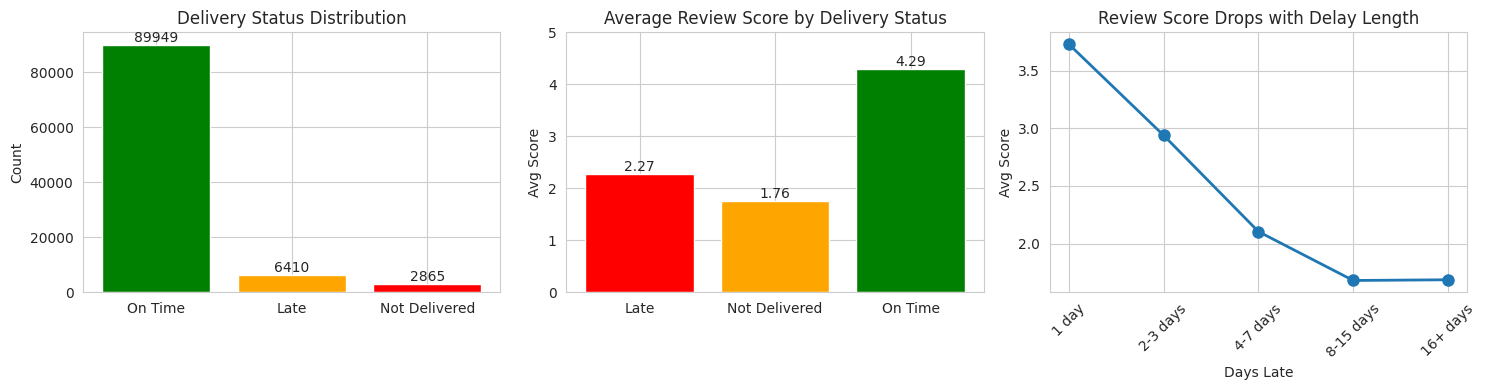


=== DELIVERY IMPACT ===
On-time orders avg score: 4.29
Late orders avg score: 2.27
Never delivered avg score: 1.76

Score drop for 1 day late: 3.73 vs on-time
Score drop for 16+ days late: 1.69 vs on-time


In [41]:
# Delivery Impact on Reviews

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Delivery status distribution
delivery_status_counts = reviews_with_orders['delivery_status'].value_counts()
axes[0].bar(delivery_status_counts.index, delivery_status_counts.values, color=['green', 'orange', 'red'])
axes[0].set_title('Delivery Status Distribution', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate(delivery_status_counts.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

# Average score by delivery status
avg_score_by_delivery = reviews_with_orders.groupby('delivery_status')['review_score'].mean()
axes[1].bar(avg_score_by_delivery.index, avg_score_by_delivery.values, color=['red', 'orange', 'green'])
axes[1].set_title('Average Review Score by Delivery Status', fontsize=12)
axes[1].set_ylabel('Avg Score')
axes[1].set_ylim(0, 5)
for i, v in enumerate(avg_score_by_delivery.values):
    axes[1].text(i, v, f'{v:.2f}', ha='center', va='bottom')

# Delay impact on score (for late deliveries)
late_reviews = reviews_with_orders[reviews_with_orders['delivery_status'] == 'Late'].copy()
late_reviews['delay_bucket'] = pd.cut(late_reviews['delivery_delay_days'], 
                                       bins=[0, 1, 3, 7, 15, 100], 
                                       labels=['1 day', '2-3 days', '4-7 days', '8-15 days', '16+ days'])
delay_impact = late_reviews.groupby('delay_bucket')['review_score'].mean()
axes[2].plot(delay_impact.index.astype(str), delay_impact.values, marker='o', linewidth=2, markersize=8)
axes[2].set_title('Review Score Drops with Delay Length', fontsize=12)
axes[2].set_xlabel('Days Late')
axes[2].set_ylabel('Avg Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n=== DELIVERY IMPACT ===")
print(f"On-time orders avg score: {avg_score_by_delivery['On Time']:.2f}")
print(f"Late orders avg score: {avg_score_by_delivery['Late']:.2f}")
print(f"Never delivered avg score: {avg_score_by_delivery['Not Delivered']:.2f}")
print(f"\nScore drop for 1 day late: {delay_impact['1 day']:.2f} vs on-time")
print(f"Score drop for 16+ days late: {delay_impact['16+ days']:.2f} vs on-time")


# Orders Review

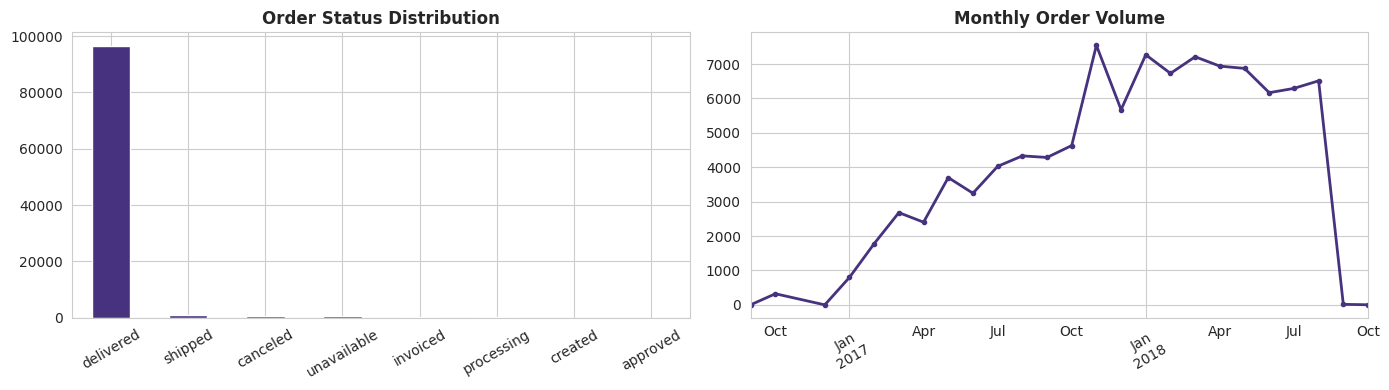

<Figure size 640x480 with 0 Axes>

Total orders: 99,441
Date range:   2016-09-04 → 2018-10-17


In [9]:
PALETTE = sns.color_palette("viridis")

# Order status distribution
status_counts = orders['order_status'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

status_counts.plot(kind='bar', ax=axes[0], color=PALETTE[0], edgecolor='white')
axes[0].set_title('Order Status Distribution', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Monthly order volume
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly = orders.groupby('year_month').size()
monthly.plot(ax=axes[1], color=PALETTE[0], linewidth=2, marker='o', markersize=3)
axes[1].set_title('Monthly Order Volume', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()
print(f'Total orders: {len(orders):,}')
print(f'Date range:   {orders["order_purchase_timestamp"].min().date()} → {orders["order_purchase_timestamp"].max().date()}')

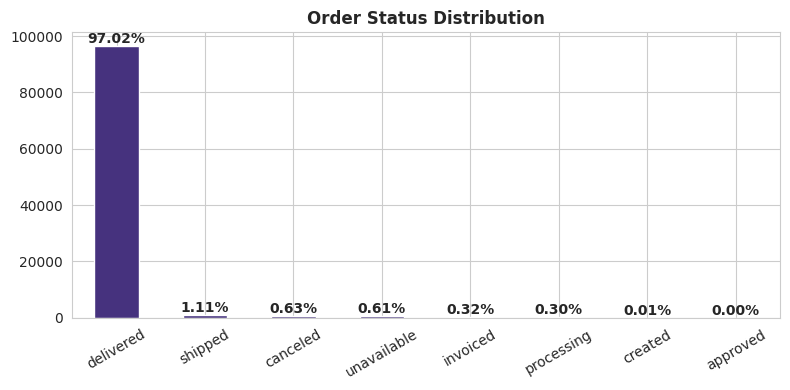

Total orders: 99,441


In [10]:
# Order status distribution
status_counts = orders['order_status'].value_counts()
status_pct = orders['order_status'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(8, 4))

bars = status_counts.plot(
    kind='bar',
    ax=ax,
    color=PALETTE[0],
    edgecolor='white'
)

ax.set_title('Order Status Distribution', fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)

# Add percentage labels on top of bars
for i, bar in enumerate(bars.patches):
    height = bar.get_height()
    pct = status_pct.iloc[i]
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{pct:.2f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

print(f'Total orders: {len(orders):,}')

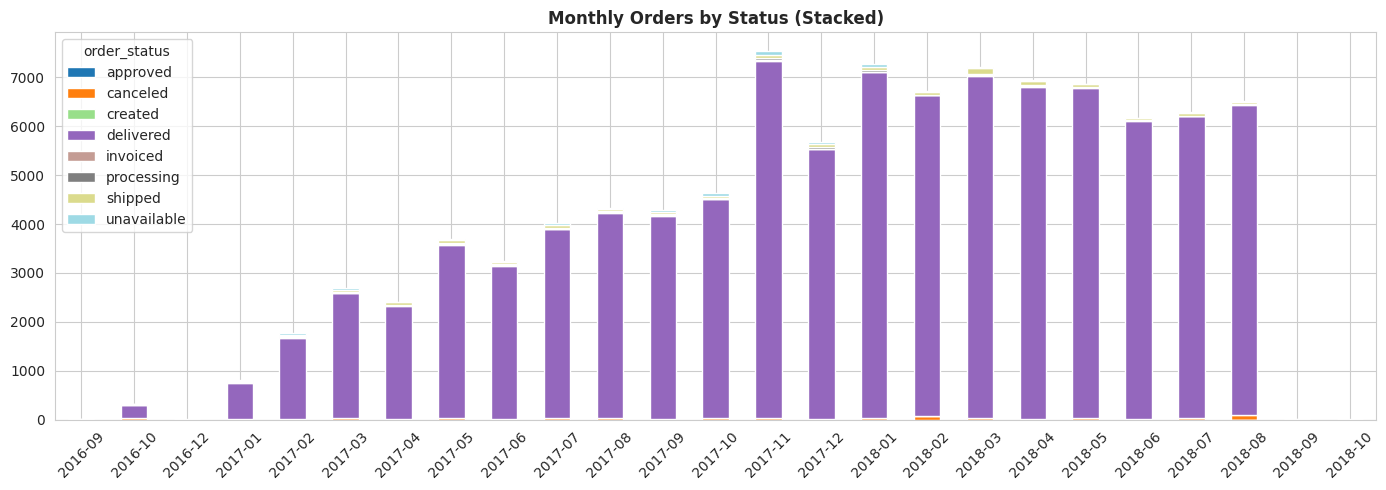

In [11]:
# Create pivot table
monthly_status = (
    orders.groupby(['year_month', 'order_status'])
    .size()
    .unstack(fill_value=0)
)

# Convert index to string for plotting
monthly_status.index = monthly_status.index.astype(str)

# Plot stacked bar
fig, ax = plt.subplots(figsize=(14,5))

monthly_status.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    colormap='tab20'
)

ax.set_title('Monthly Orders by Status (Stacked)', fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

order_status  approved    canceled   created   delivered  invoiced  \
year_month                                                           
2016-09       0.000000   50.000000  0.000000   25.000000  0.000000   
2016-10       0.000000    7.407407  0.000000   81.790123  5.555556   
2016-12       0.000000    0.000000  0.000000  100.000000  0.000000   
2017-01       0.000000    0.375000  0.000000   93.750000  1.500000   
2017-02       0.056180    0.955056  0.000000   92.865169  0.617978   
2017-03       0.000000    1.230425  0.000000   94.929157  0.111857   
2017-04       0.041597    0.748752  0.000000   95.798669  0.582363   
2017-05       0.000000    0.783784  0.000000   95.837838  0.432432   
2017-06       0.000000    0.493066  0.000000   96.610169  0.338983   
2017-07       0.000000    0.695479  0.000000   96.174863  0.173870   
2017-08       0.000000    0.623413  0.000000   96.813669  0.461787   
2017-09       0.000000    0.466744  0.000000   96.849475  0.396733   
2017-10       0.0000

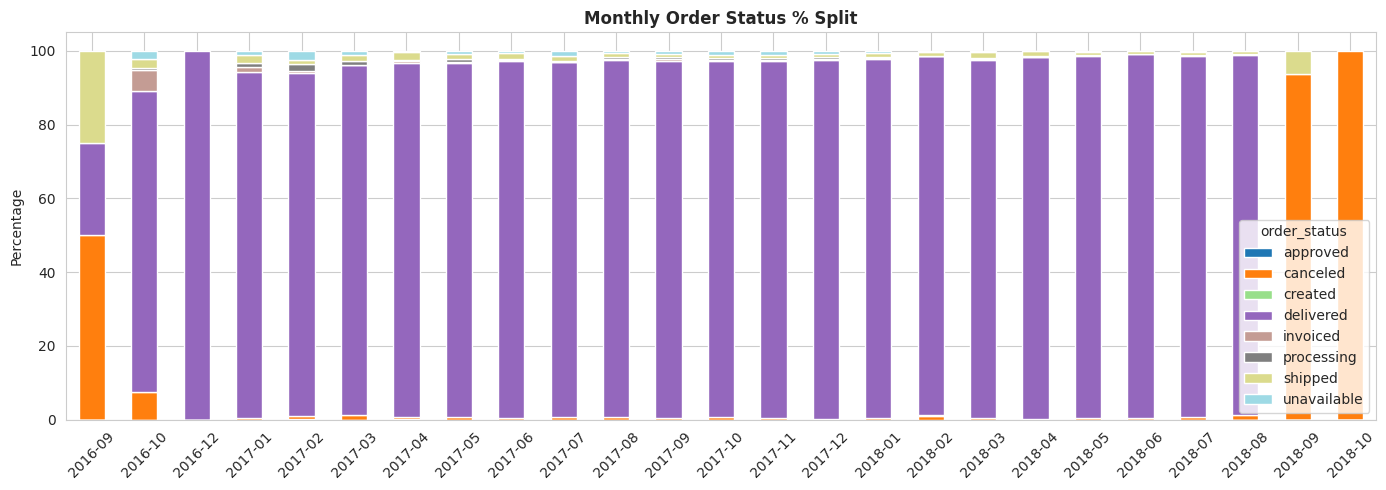

In [12]:
monthly_status_pct = monthly_status.div(
    monthly_status.sum(axis=1),
    axis=0
) * 100

print(monthly_status_pct)
fig, ax = plt.subplots(figsize=(14,5))

monthly_status_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    colormap='tab20'
)

ax.set_title('Monthly Order Status % Split', fontweight='bold')
ax.set_ylabel('Percentage')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Late Delivery Analysis

How often are orders late?

Late delivery rate: 6.8%  (6,534 / 96,478 orders)

Delay stats (days):
count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000


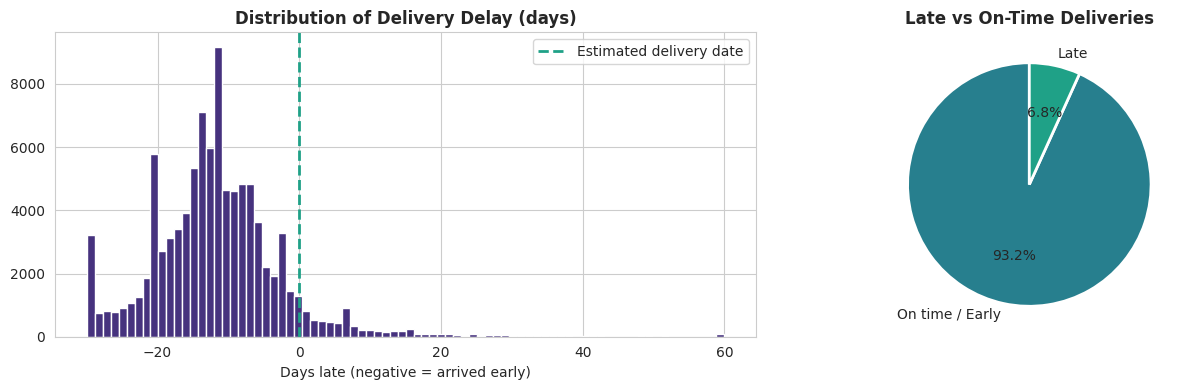

In [13]:
# Filter to delivered orders only
delivered = orders[orders['order_status'] == 'delivered'].copy()

# Compute delivery delay in days (positive = late, negative = early)
delivered['delay_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']
).dt.days

delivered['is_late'] = delivered['delay_days'] > 0

late_rate = delivered['is_late'].mean() * 100
print(f'Late delivery rate: {late_rate:.1f}%  ({delivered["is_late"].sum():,} / {len(delivered):,} orders)')
print(f'\nDelay stats (days):')
print(delivered['delay_days'].describe().to_string())

# Plot delay distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(delivered['delay_days'].clip(-30, 60), bins=80, color=PALETTE[0], edgecolor='white')
axes[0].axvline(0, color=PALETTE[3], linewidth=2, linestyle='--', label='Estimated delivery date')
axes[0].set_title('Distribution of Delivery Delay (days)', fontweight='bold')
axes[0].set_xlabel('Days late (negative = arrived early)')
axes[0].legend()

labels = ['On time / Early', 'Late']
sizes  = [1 - delivered['is_late'].mean(), delivered['is_late'].mean()]
axes[1].pie(sizes, labels=labels, colors=[PALETTE[2], PALETTE[3]],
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Late vs On-Time Deliveries', fontweight='bold')

plt.tight_layout()
plt.show()

Does late delivery drive bad reviews?

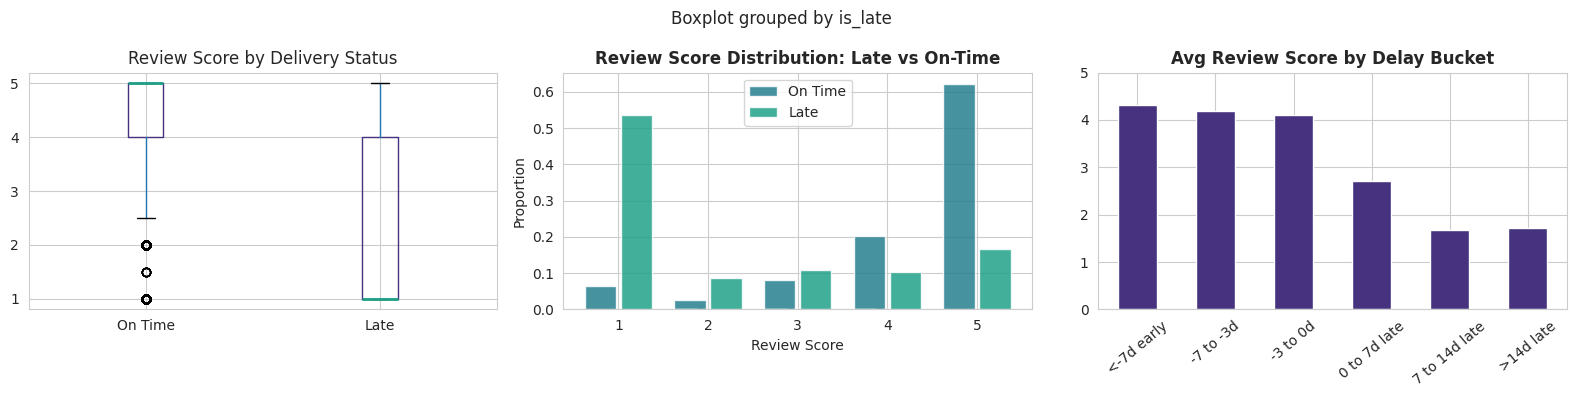


Average review score:
             mean  median  count
is_late                         
On Time  4.290608     5.0  89451
Late     2.271823     1.0   6381


In [14]:
# Merge reviews onto delivered orders
rev_agg = reviews.groupby('order_id')['review_score'].mean().reset_index()
df_rev  = delivered.merge(rev_agg, on='order_id', how='left')

# Average review score by on-time status
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Box plot
df_rev.boxplot(column='review_score', by='is_late', ax=axes[0],
               boxprops=dict(color=PALETTE[0]),
               medianprops=dict(color=PALETTE[3], linewidth=2))
axes[0].set_title('Review Score by Delivery Status', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['On Time', 'Late'])
plt.sca(axes[0]); plt.title('Review Score by Delivery Status')

# Review score distribution by late flag
for late_val, label, color in [(False, 'On Time', PALETTE[2]), (True, 'Late', PALETTE[3])]:
    subset = df_rev[df_rev['is_late'] == late_val]['review_score'].value_counts(normalize=True).sort_index()
    axes[1].bar(subset.index + (0.2 if late_val else -0.2), subset.values,
                width=0.35, label=label, color=color, alpha=0.85)
axes[1].set_title('Review Score Distribution: Late vs On-Time', fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Proportion')
axes[1].legend()

# Average score by delay bucket
bins   = [-np.inf, -7, -3, 0, 7, 14, np.inf]
labels = ['<-7d early', '-7 to -3d', '-3 to 0d', '0 to 7d late', '7 to 14d late', '>14d late']
df_rev['delay_bucket'] = pd.cut(df_rev['delay_days'], bins=bins, labels=labels)
avg_by_bucket = df_rev.groupby('delay_bucket', observed=True)['review_score'].mean()
avg_by_bucket.plot(kind='bar', ax=axes[2], color=PALETTE[0], edgecolor='white')
axes[2].set_title('Avg Review Score by Delay Bucket', fontweight='bold')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=40)
axes[2].set_ylim(0, 5)

plt.tight_layout()
plt.show()

print('\nAverage review score:')
print(df_rev.groupby('is_late')['review_score'].agg(['mean','median','count']).rename(index={False:'On Time', True:'Late'}))

Delivery delay by product category

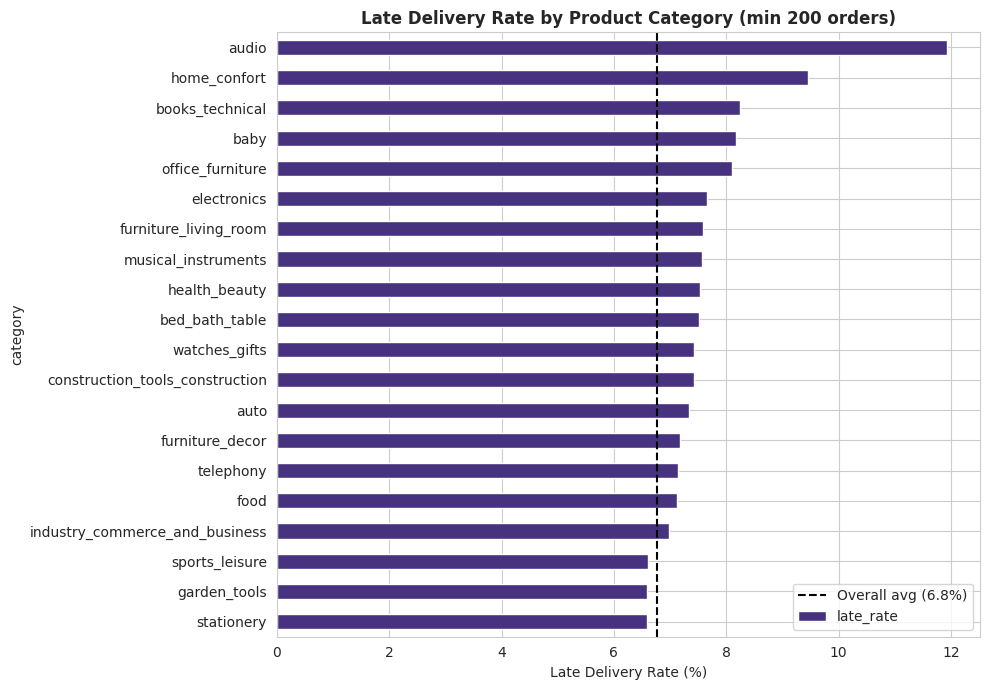

In [15]:
# Join products & category translations
products_en = products.merge(cat_trans, on='product_category_name', how='left')
products_en['category'] = products_en['product_category_name_english'].fillna(products_en['product_category_name'])

items_prod = order_items.merge(products_en[['product_id', 'category', 'product_weight_g',
                                             'product_length_cm', 'product_height_cm', 'product_width_cm']],
                                on='product_id', how='left')

# One category per order (first item)
order_cat = items_prod.groupby('order_id')[['category', 'product_weight_g']].first().reset_index()
df_cat    = delivered.merge(order_cat, on='order_id', how='left')

# Top 20 categories by order count — late rate
cat_stats = (df_cat.groupby('category')
               .agg(order_count=('order_id', 'count'), late_rate=('is_late', 'mean'))
               .query('order_count >= 200')
               .sort_values('late_rate', ascending=True)
               .tail(20))

fig, ax = plt.subplots(figsize=(10, 7))
colors  = [PALETTE[3] if r > 0.15 else PALETTE[0] for r in cat_stats['late_rate']]
cat_stats['late_rate'].mul(100).plot(kind='barh', ax=ax, color=colors)
ax.set_title('Late Delivery Rate by Product Category (min 200 orders)', fontweight='bold')
ax.set_xlabel('Late Delivery Rate (%)')
ax.axvline(late_rate, color='black', linestyle='--', linewidth=1.5, label=f'Overall avg ({late_rate:.1f}%)')
ax.legend()
plt.tight_layout()
plt.show()

Delivery delay by seller state

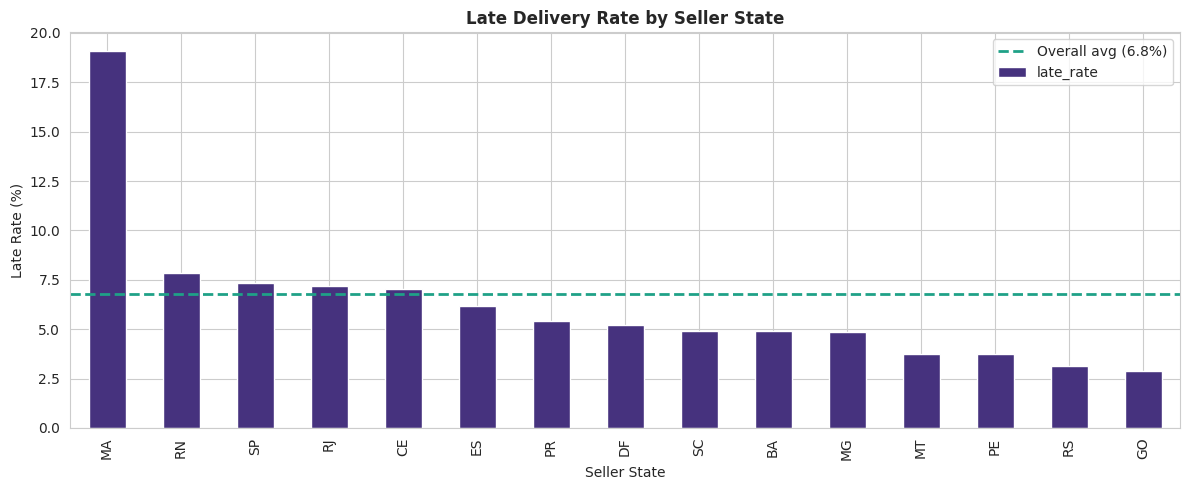

In [16]:
# Join seller state onto orders
item_seller = order_items[['order_id', 'seller_id']].drop_duplicates('order_id')
df_sel = delivered.merge(item_seller, on='order_id', how='left').merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
df_cust = df_sel.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

seller_late = (df_cust.groupby('seller_state')
                 .agg(order_count=('order_id','count'), late_rate=('is_late','mean'))
                 .query('order_count >= 50')
                 .sort_values('late_rate', ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
seller_late['late_rate'].mul(100).plot(kind='bar', ax=ax, color=PALETTE[0], edgecolor='white')
ax.axhline(late_rate, color=PALETTE[3], linestyle='--', linewidth=2, label=f'Overall avg ({late_rate:.1f}%)')
ax.set_title('Late Delivery Rate by Seller State', fontweight='bold')
ax.set_xlabel('Seller State')
ax.set_ylabel('Late Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

Freight vs Weight 

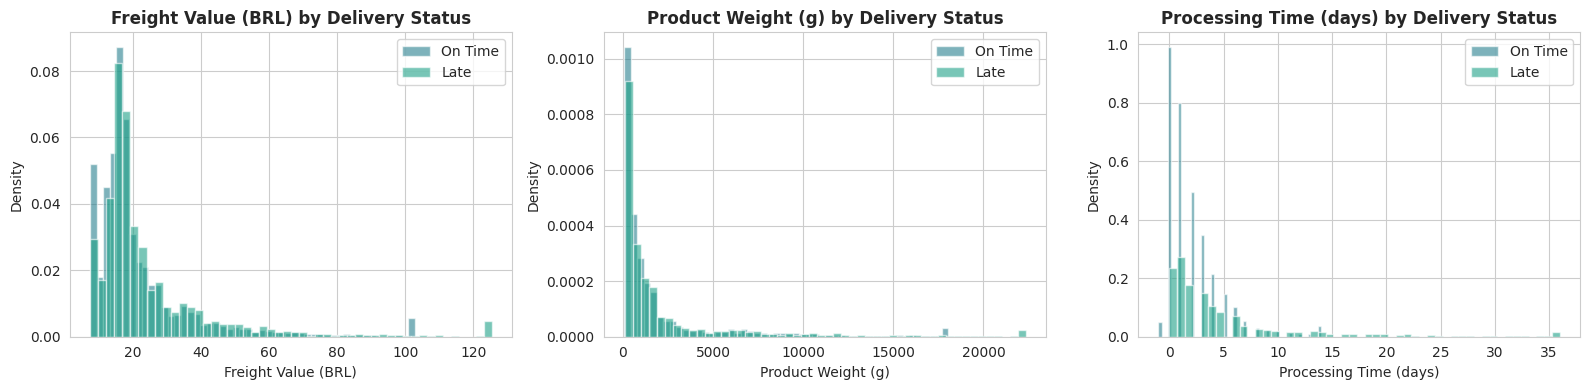


Mean values by delivery status:
         total_freight  product_weight_g  processing_days  estimated_window
is_late                                                                    
On Time      22.606376       2071.081376         2.095442         23.451392
Late         25.247596       2464.747781         5.052503         22.290328


In [17]:
df_feat = delivered.merge(order_items[['order_id','freight_value','price','product_id']].groupby('order_id').agg(
    total_freight=('freight_value','sum'),
    total_price=('price','sum'),
    n_items=('product_id','count')
).reset_index(), on='order_id', how='left')

df_feat = df_feat.merge(order_cat[['order_id','product_weight_g']], on='order_id', how='left')

# Compute approval-to-carrier time (seller processing time)
df_feat['processing_days'] = (df_feat['order_delivered_carrier_date'] - df_feat['order_approved_at']).dt.days
df_feat['estimated_window'] = (df_feat['order_estimated_delivery_date'] - df_feat['order_purchase_timestamp']).dt.days

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, label in zip(axes, 
                           ['total_freight', 'product_weight_g', 'processing_days'],
                           ['Freight Value (BRL)', 'Product Weight (g)', 'Processing Time (days)']):
    for late_val, lbl, color in [(False, 'On Time', PALETTE[2]), (True, 'Late', PALETTE[3])]:
        vals = df_feat[df_feat['is_late'] == late_val][col].dropna()
        vals = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
        ax.hist(vals, bins=50, alpha=0.6, label=lbl, color=color, density=True)
    ax.set_title(f'{label} by Delivery Status', fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

print('\nMean values by delivery status:')
print(df_feat.groupby('is_late')[['total_freight','product_weight_g','processing_days','estimated_window']]
      .mean().rename(index={False:'On Time', True:'Late'}))

Seasonality — does time of year matter?

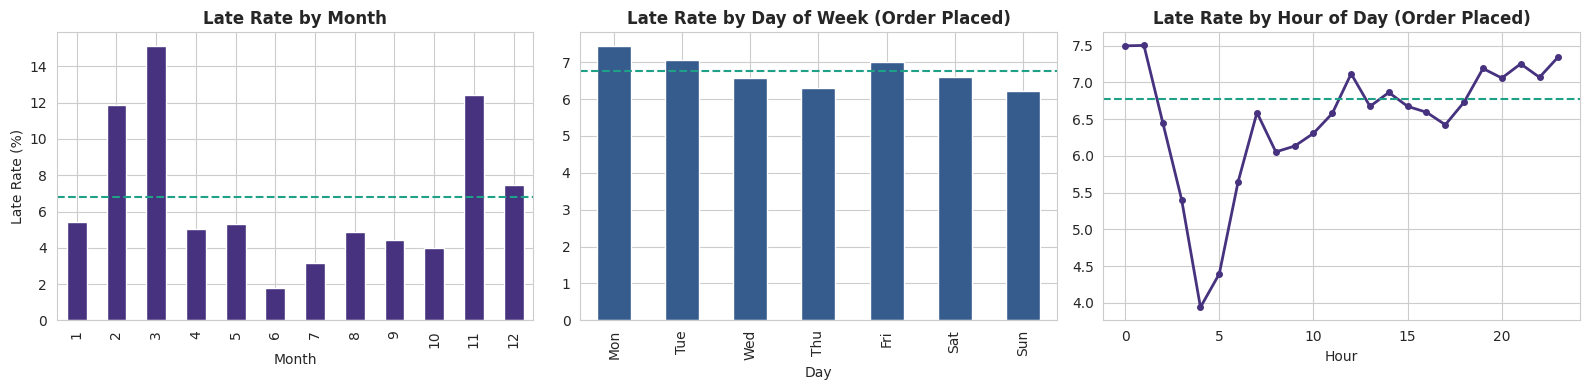

In [18]:
delivered['month'] = delivered['order_purchase_timestamp'].dt.month
delivered['dow']   = delivered['order_purchase_timestamp'].dt.dayofweek  # 0=Mon
delivered['hour']  = delivered['order_purchase_timestamp'].dt.hour

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

month_late = delivered.groupby('month')['is_late'].mean() * 100
month_late.plot(kind='bar', ax=axes[0], color=PALETTE[0], edgecolor='white')
axes[0].set_title('Late Rate by Month', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Late Rate (%)')
axes[0].axhline(late_rate, color=PALETTE[3], linestyle='--')

dow_late = delivered.groupby('dow')['is_late'].mean() * 100
dow_late.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_late.plot(kind='bar', ax=axes[1], color=PALETTE[1], edgecolor='white')
axes[1].set_title('Late Rate by Day of Week (Order Placed)', fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].axhline(late_rate, color=PALETTE[3], linestyle='--')

hour_late = delivered.groupby('hour')['is_late'].mean() * 100
hour_late.plot(ax=axes[2], color=PALETTE[0], linewidth=2, marker='o', markersize=4)
axes[2].set_title('Late Rate by Hour of Day (Order Placed)', fontweight='bold')
axes[2].set_xlabel('Hour')
axes[2].axhline(late_rate, color=PALETTE[3], linestyle='--')

plt.tight_layout()
plt.show()

# Seller Health Analysis

Seller performance distribution

In [19]:
# Build seller-level metrics
seller_orders = order_items[['order_id','seller_id','price','freight_value']].merge(
    orders[['order_id','order_purchase_timestamp','order_status']], on='order_id')

seller_stats = (seller_orders.groupby('seller_id').agg(
    total_orders    = ('order_id',  'nunique'),
    total_revenue   = ('price',     'sum'),
    avg_order_value = ('price',     'mean'),
    first_order     = ('order_purchase_timestamp', 'min'),
    last_order      = ('order_purchase_timestamp', 'max'),
).reset_index())

# Review scores per seller
seller_rev = (order_items[['order_id','seller_id']]
              .merge(rev_agg, on='order_id', how='left')
              .groupby('seller_id')['review_score'].agg(['mean','count'])
              .rename(columns={'mean':'avg_review_score','count':'review_count'})
              .reset_index())

# Late delivery rate per seller
seller_late = (df_sel.groupby('seller_id')
               .agg(late_rate=('is_late','mean'), delivered_count=('order_id','count'))
               .reset_index())

seller_df = (seller_stats
             .merge(seller_rev,  on='seller_id', how='left')
             .merge(seller_late, on='seller_id', how='left'))

# Tenure in days
seller_df['tenure_days'] = (seller_df['last_order'] - seller_df['first_order']).dt.days

print(f'Total sellers: {len(seller_df):,}')
print('\nSeller stats summary:')
print(seller_df[['total_orders','total_revenue','avg_review_score','late_rate','tenure_days']].describe())

Total sellers: 3,095

Seller stats summary:
       total_orders  total_revenue  avg_review_score    late_rate  tenure_days
count   3095.000000    3095.000000       3090.000000  2960.000000  3095.000000
mean      32.313409    4391.484233          3.972987     0.070258   175.846850
std      105.139763   13921.997192          0.971256     0.157928   181.957566
min        1.000000       3.500000          1.000000     0.000000     0.000000
25%        2.000000     208.850000          3.714286     0.000000    18.000000
50%        6.000000     821.480000          4.166667     0.000000   112.000000
75%       21.500000    3280.830000          4.600000     0.078850   287.000000
max     1854.000000  229472.630000          5.000000     1.000000   709.000000


Revenue concentration

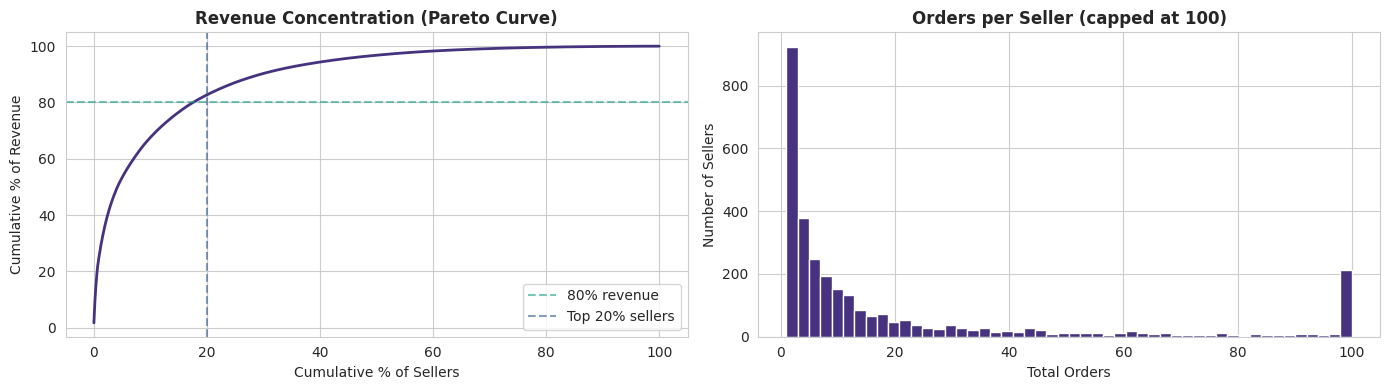

Top 20% of sellers generate 82.7% of revenue


In [20]:
seller_sorted = seller_df.sort_values('total_revenue', ascending=False).reset_index(drop=True)
seller_sorted['cum_revenue_pct'] = seller_sorted['total_revenue'].cumsum() / seller_sorted['total_revenue'].sum() * 100
seller_sorted['seller_pct']      = (seller_sorted.index + 1) / len(seller_sorted) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(seller_sorted['seller_pct'], seller_sorted['cum_revenue_pct'],
             color=PALETTE[0], linewidth=2)
axes[0].axhline(80, color=PALETTE[3], linestyle='--', alpha=0.6, label='80% revenue')
axes[0].axvline(20, color=PALETTE[1], linestyle='--', alpha=0.6, label='Top 20% sellers')
axes[0].set_title('Revenue Concentration (Pareto Curve)', fontweight='bold')
axes[0].set_xlabel('Cumulative % of Sellers')
axes[0].set_ylabel('Cumulative % of Revenue')
axes[0].legend()

# Orders per seller distribution
axes[1].hist(seller_df['total_orders'].clip(0, 100), bins=50, color=PALETTE[0], edgecolor='white')
axes[1].set_title('Orders per Seller (capped at 100)', fontweight='bold')
axes[1].set_xlabel('Total Orders')
axes[1].set_ylabel('Number of Sellers')

plt.tight_layout()
plt.show()

top20_pct = seller_sorted.iloc[:int(len(seller_sorted)*0.2)]['cum_revenue_pct'].max()
print(f'Top 20% of sellers generate {top20_pct:.1f}% of revenue')

Review score vs. Late rate — seller quadrant analysis

/tmp/ipykernel_55/218112465.py:33: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/218112465.py:33: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


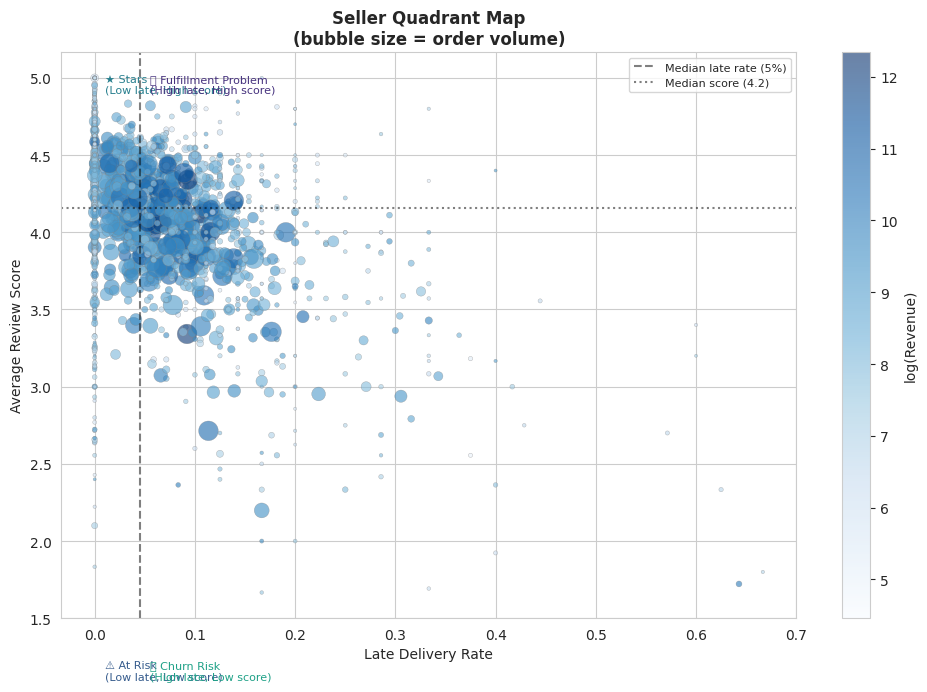

In [21]:
# Filter sellers with enough data to be meaningful
sel_plot = seller_df[(seller_df['review_count'] >= 5) & (seller_df['delivered_count'] >= 5)].copy()

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    sel_plot['late_rate'],
    sel_plot['avg_review_score'],
    c=np.log1p(sel_plot['total_revenue']),
    cmap='Blues',
    alpha=0.6,
    edgecolors='grey',
    linewidth=0.3,
    s=sel_plot['total_orders'].clip(1, 200)
)
plt.colorbar(scatter, ax=ax, label='log(Revenue)')

med_late  = sel_plot['late_rate'].median()
med_score = sel_plot['avg_review_score'].median()
ax.axvline(med_late,  color='black', linestyle='--', alpha=0.5, label=f'Median late rate ({med_late:.0%})')
ax.axhline(med_score, color='black', linestyle=':',  alpha=0.5, label=f'Median score ({med_score:.1f})')

# Quadrant labels
ax.text(0.01, 4.9, '★ Stars\n(Low late, High score)', fontsize=8, color=PALETTE[2])
ax.text(0.01, 1.1, '⚠ At Risk\n(Low late, Low score)',  fontsize=8, color=PALETTE[1])
ax.text(med_late + 0.01, 4.9, '⏰ Fulfillment Problem\n(High late, High score)', fontsize=8, color=PALETTE[0])
ax.text(med_late + 0.01, 1.1, '🚨 Churn Risk\n(High late, Low score)',   fontsize=8, color=PALETTE[3])

ax.set_xlabel('Late Delivery Rate')
ax.set_ylabel('Average Review Score')
ax.set_title('Seller Quadrant Map\n(bubble size = order volume)', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

Seller activity trends — proxy for churn

Sellers inactive >90 days: 1,289 (41.6%)


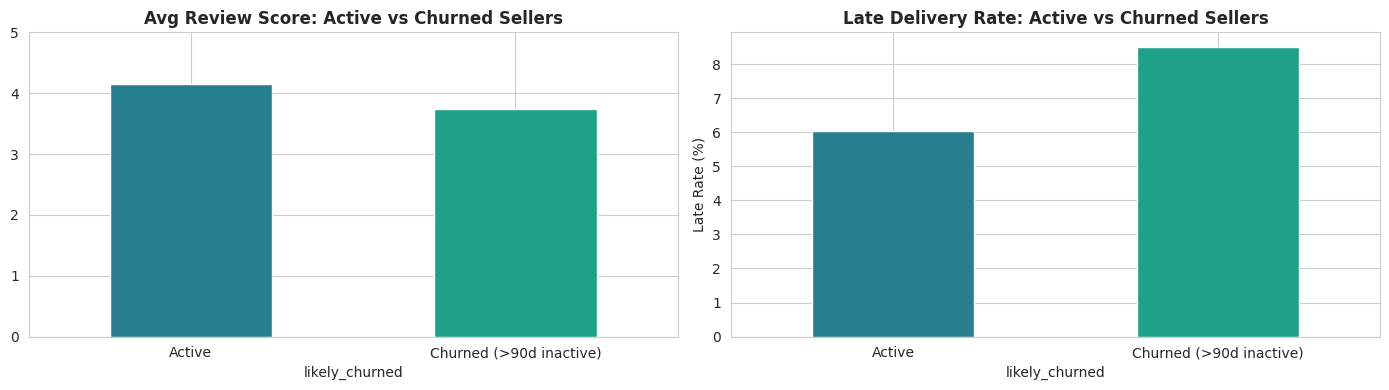

In [22]:
# Flag sellers whose last order was >90 days before dataset end
max_date  = seller_df['last_order'].max()
seller_df['days_since_last_order'] = (max_date - seller_df['last_order']).dt.days
seller_df['likely_churned']        = seller_df['days_since_last_order'] > 90

churn_rate = seller_df['likely_churned'].mean() * 100
print(f'Sellers inactive >90 days: {seller_df["likely_churned"].sum():,} ({churn_rate:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Review score for churned vs active
churned_rev = seller_df.groupby('likely_churned')['avg_review_score'].mean().rename({False:'Active', True:'Churned'})
churned_rev.plot(kind='bar', ax=axes[0], color=[PALETTE[2], PALETTE[3]], edgecolor='white')
axes[0].set_title('Avg Review Score: Active vs Churned Sellers', fontweight='bold')
axes[0].set_xticklabels(['Active', 'Churned (>90d inactive)'], rotation=0)
axes[0].set_ylim(0, 5)

# Late rate for churned vs active
churned_late = seller_df.groupby('likely_churned')['late_rate'].mean().rename({False:'Active', True:'Churned'})
churned_late.mul(100).plot(kind='bar', ax=axes[1], color=[PALETTE[2], PALETTE[3]], edgecolor='white')
axes[1].set_title('Late Delivery Rate: Active vs Churned Sellers', fontweight='bold')
axes[1].set_xticklabels(['Active', 'Churned (>90d inactive)'], rotation=0)
axes[1].set_ylabel('Late Rate (%)')

plt.tight_layout()
plt.show()

Payment & Revenue Patterns

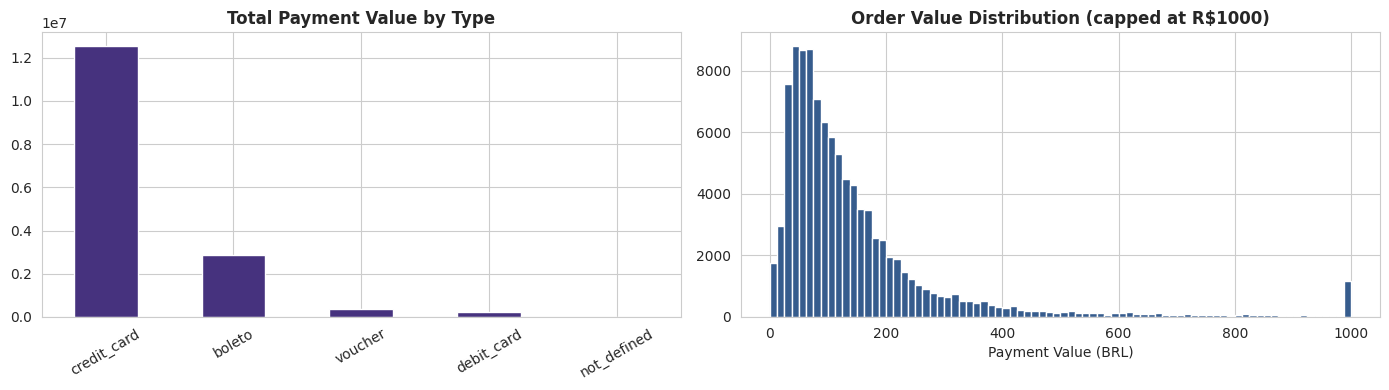


Payment stats:
                      sum        mean  count
payment_type                                
boleto         2869361.27  145.034435  19784
credit_card   12542084.19  163.319021  76795
debit_card      217989.79  142.570170   1529
not_defined          0.00    0.000000      3
voucher         379436.87   65.703354   5775


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pay_type = payments.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)
pay_type.plot(kind='bar', ax=axes[0], color=PALETTE[0], edgecolor='white')
axes[0].set_title('Total Payment Value by Type', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

axes[1].hist(payments['payment_value'].clip(0, 1000), bins=80, color=PALETTE[1], edgecolor='white')
axes[1].set_title('Order Value Distribution (capped at R$1000)', fontweight='bold')
axes[1].set_xlabel('Payment Value (BRL)')

plt.tight_layout()
plt.show()
print('\nPayment stats:')
print(payments.groupby('payment_type')['payment_value'].agg(['sum','mean','count']))

Correlation Heatmap — Potential ML Features

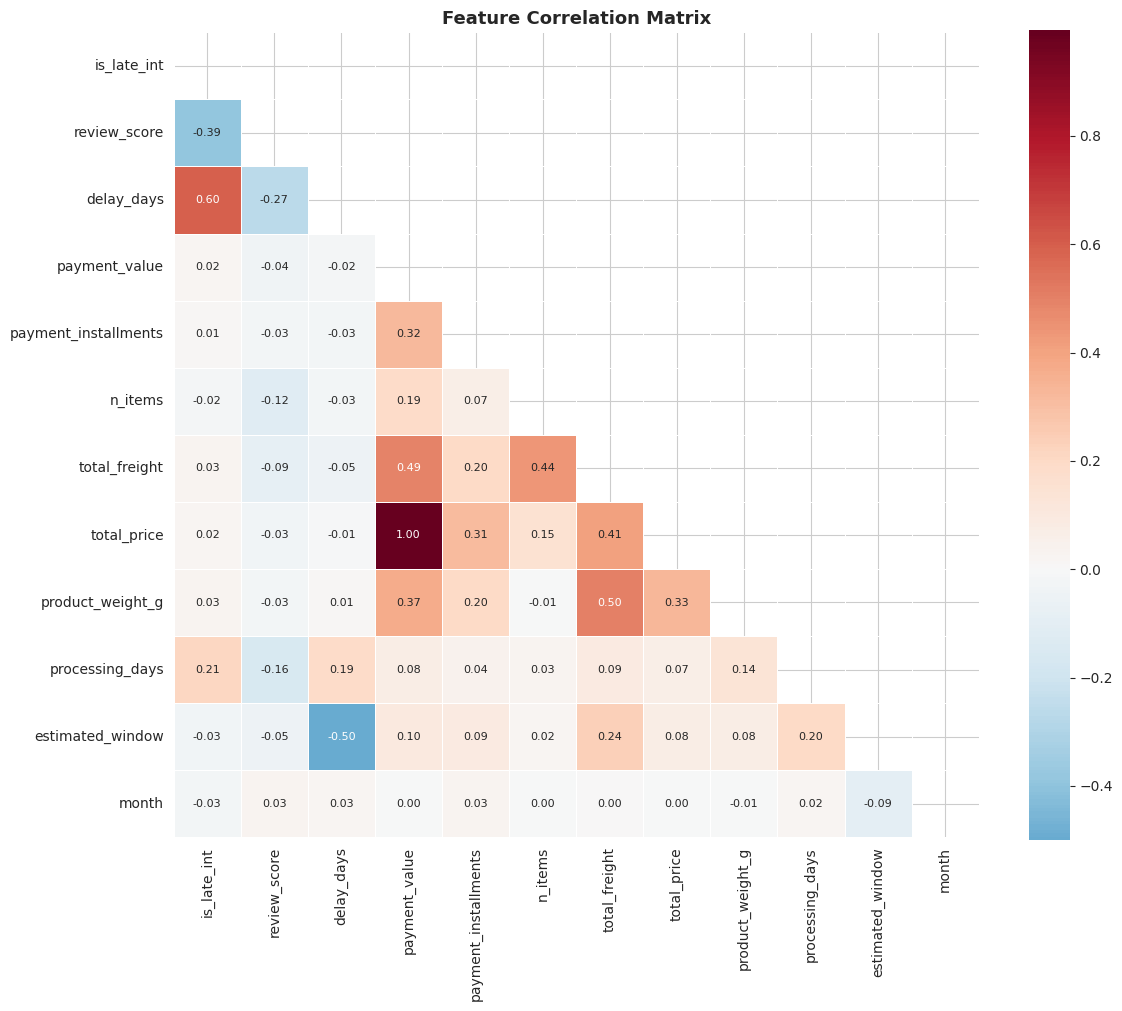


Top correlations with is_late:
delay_days              0.595516
review_score           -0.392086
processing_days         0.209430
estimated_window       -0.033312
total_freight           0.030784
month                  -0.030491
product_weight_g        0.026351
payment_value           0.020083
total_price             0.017857
n_items                -0.015245
payment_installments    0.012549


In [24]:
# Build a wide feature table for correlation analysis
pay_agg = payments.groupby('order_id').agg(
    payment_value    = ('payment_value', 'sum'),
    payment_installments = ('payment_installments', 'max')
).reset_index()

items_agg = order_items.groupby('order_id').agg(
    n_items        = ('product_id', 'count'),
    total_freight  = ('freight_value', 'sum'),
    total_price    = ('price', 'sum')
).reset_index()

feature_df = (delivered
              .merge(pay_agg,   on='order_id', how='left')
              .merge(items_agg, on='order_id', how='left')
              .merge(order_cat, on='order_id', how='left')
              .merge(rev_agg,   on='order_id', how='left'))

feature_df['processing_days']    = (feature_df['order_delivered_carrier_date'] - feature_df['order_approved_at']).dt.days
feature_df['estimated_window']   = (feature_df['order_estimated_delivery_date'] - feature_df['order_purchase_timestamp']).dt.days
feature_df['month']              = feature_df['order_purchase_timestamp'].dt.month
feature_df['is_late_int']        = feature_df['is_late'].astype(int)

corr_cols = ['is_late_int','review_score','delay_days','payment_value','payment_installments',
             'n_items','total_freight','total_price','product_weight_g','processing_days',
             'estimated_window','month']

corr = feature_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('\nTop correlations with is_late:')
print(corr['is_late_int'].drop('is_late_int').sort_values(key=abs, ascending=False).to_string())

Geographic Analysis

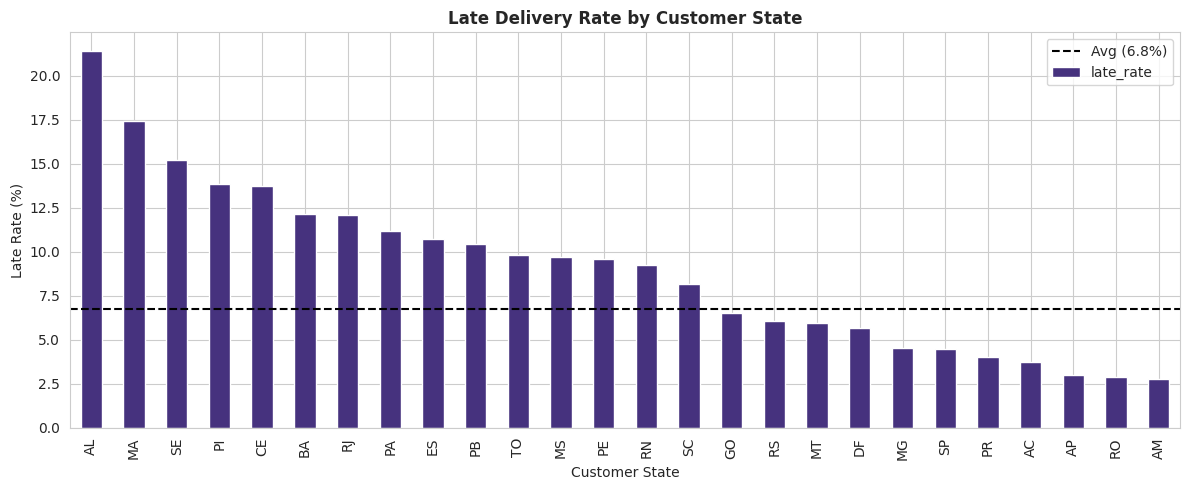

In [25]:
# Customer state late rates
cust_state_late = (df_cust.groupby('customer_state')
                   .agg(order_count=('order_id','count'), late_rate=('is_late','mean'))
                   .query('order_count >= 50')
                   .sort_values('late_rate', ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
bars = cust_state_late['late_rate'].mul(100).plot(kind='bar', ax=ax, edgecolor='white')
colors_bar = [PALETTE[3] if r > late_rate else PALETTE[0] for r in cust_state_late['late_rate']]
for patch, color in zip(ax.patches, colors_bar):
    patch.set_facecolor(color)
ax.axhline(late_rate, color='black', linestyle='--', linewidth=1.5, label=f'Avg ({late_rate:.1f}%)')
ax.set_title('Late Delivery Rate by Customer State', fontweight='bold')
ax.set_xlabel('Customer State')
ax.set_ylabel('Late Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

Review Text — Quick Sentiment Check

In [26]:
# What do 1-star reviews mention? Quick keyword scan (Portuguese keywords)
low_reviews  = reviews[reviews['review_score'] == 1]['review_comment_message'].dropna().str.lower()
high_reviews = reviews[reviews['review_score'] == 5]['review_comment_message'].dropna().str.lower()

delivery_keywords = ['prazo', 'entrega', 'atraso', 'chegou', 'demorou', 'demora',
                     'prazo', 'transportadora', 'correios']

print('1-Star review keyword hit rates (delivery-related):')
for kw in delivery_keywords:
    low_hit  = low_reviews.str.contains(kw).mean() * 100
    high_hit = high_reviews.str.contains(kw).mean() * 100
    print(f'  "{kw:20s}"  1-star: {low_hit:5.1f}%   5-star: {high_hit:5.1f}%')

print(f'\nShare of 1-star reviews with a comment: {low_reviews.shape[0] / (reviews["review_score"]==1).sum():.1%}')
print(f'Share of 5-star reviews with a comment: {high_reviews.shape[0] / (reviews["review_score"]==5).sum():.1%}')

1-Star review keyword hit rates (delivery-related):
  "prazo               "  1-star:   7.7%   5-star:  27.6%
  "entrega             "  1-star:  15.9%   5-star:  18.8%
  "atraso              "  1-star:   1.8%   5-star:   0.2%
  "chegou              "  1-star:  10.2%   5-star:  15.4%
  "demorou             "  1-star:   0.8%   5-star:   0.3%
  "demora              "  1-star:   2.6%   5-star:   0.3%
  "prazo               "  1-star:   7.7%   5-star:  27.6%
  "transportadora      "  1-star:   0.4%   5-star:   0.1%
  "correios            "  1-star:   2.9%   5-star:   0.6%

Share of 1-star reviews with a comment: 76.5%
Share of 5-star reviews with a comment: 35.9%


EDA Summary & ML Readiness Check

In [27]:
print('='*65)
print('EDA SUMMARY — ML READINESS')
print('='*65)

print(f"""
PROBLEM 1: Late Delivery Prediction
------------------------------------
  Target variable    : is_late (binary)
  Positive class rate: {late_rate:.1f}%  ← class imbalance to handle
  Deliverable rows   : {len(delivered):,}
  Usable features    : processing_days, estimated_window, product_weight_g,
                       total_freight, seller_state, customer_state, category,
                       month, day_of_week, n_items, payment_installments
  Key finding        : Late orders score {df_rev[df_rev['is_late']]['review_score'].mean():.2f} vs
                       {df_rev[~df_rev['is_late']]['review_score'].mean():.2f} on time → strong business ROI
  Recommended model  : XGBoost / LightGBM classifier
  Key risk           : processing_days uses carrier date — not available at order placement!
                       Must engineer features using ONLY data available at order time.

PROBLEM 2: Seller Churn Prediction
------------------------------------
  Target variable    : likely_churned (proxy: inactive >90 days)
  Positive class rate: {seller_df['likely_churned'].mean()*100:.1f}%
  Seller rows        : {len(seller_df):,}
  Usable features    : avg_review_score, late_rate, total_orders,
                       total_revenue, tenure_days, review_count, seller_state
  Key finding        : Churned sellers have lower review scores & higher late rates
  Recommended model  : Logistic Regression or Gradient Boosted Trees
  Key risk           : Churn label is proxied — needs business validation on
                       true churn definition (voluntary vs. account suspension)
""")
print('='*65)
print('NEXT STEPS:')
print('  1. Feature engineering notebook (strictly pre-order features)')
print('  2. Baseline model training + cross-validation')
print('  3. SHAP explainability for business buy-in')
print('  4. Threshold selection based on ops team cost/benefit')
print('='*65)

EDA SUMMARY — ML READINESS

PROBLEM 1: Late Delivery Prediction
------------------------------------
  Target variable    : is_late (binary)
  Positive class rate: 6.8%  ← class imbalance to handle
  Deliverable rows   : 96,478
  Usable features    : processing_days, estimated_window, product_weight_g,
                       total_freight, seller_state, customer_state, category,
                       month, day_of_week, n_items, payment_installments
  Key finding        : Late orders score 2.27 vs
                       4.29 on time → strong business ROI
  Recommended model  : XGBoost / LightGBM classifier
  Key risk           : processing_days uses carrier date — not available at order placement!
                       Must engineer features using ONLY data available at order time.

PROBLEM 2: Seller Churn Prediction
------------------------------------
  Target variable    : likely_churned (proxy: inactive >90 days)
  Positive class rate: 41.6%
  Seller rows        : 3,095
  Usable 